# ver15 Presentation Summary

이 노트북은 모델을 다시 학습하지 않습니다.

이미 저장된 `ver10~ver14` 결과 CSV를 불러와서 발표용 표, 그래프, 파이프라인 그림, 요약문을 생성합니다.

산출물 저장 위치:

`C:\Users\user\alzheimer\presentation_assets`

PPT에 바로 넣을 수 있는 파일:

- `final_model_comparison_table.csv`
- `final_model_comparison_table.png`
- `main_5fold_metric_comparison.png`
- `sensitivity_specificity_scatter.png`
- `parameter_efficiency.png`
- `fold1_peft_comparison.png`
- `pipeline_diagram.png`
- `presentation_summary.md`


## 1. 라이브러리 및 경로 설정


In [1]:
from pathlib import Path
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"C:\Users\user\alzheimer")
ASSET_DIR = PROJECT_DIR / "presentation_assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "foundation_summary": PROJECT_DIR / "patient_level_stage1_foundation" / "non_vs_demented_biomedclip_summary.csv",
    "foundation_folds": PROJECT_DIR / "patient_level_stage1_foundation" / "non_vs_demented_biomedclip_fold_results.csv",
    "cnn_summary": PROJECT_DIR / "patient_level_stage1" / "sensitivity_first" / "sensitivity_target_summary.csv",
    "lora_summary": PROJECT_DIR / "patient_level_stage1_lora_5fold_stable" / "non_vs_demented_biomedclip_lora_5fold_stable_summary.csv",
    "lora_folds": PROJECT_DIR / "patient_level_stage1_lora_5fold_stable" / "non_vs_demented_biomedclip_lora_5fold_stable_fold_results.csv",
    "internal_adapter_summary": PROJECT_DIR / "patient_level_stage1_internal_adapter_fold1" / "non_vs_demented_biomedclip_internal_adapter_fold1_summary.csv",
    "internal_adapter_folds": PROJECT_DIR / "patient_level_stage1_internal_adapter_fold1" / "non_vs_demented_biomedclip_internal_adapter_fold1_fold_results.csv",
}

BIOMEDCLIP_TOTAL_PARAMS = 195_902_721

try:
    plt.rcParams["font.family"] = "Malgun Gothic"
except Exception:
    pass
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220

for name, path in PATHS.items():
    print(f"{name:24s}: {'OK' if path.exists() else 'MISSING'} | {path}")
print(f"ASSET_DIR: {ASSET_DIR}")


foundation_summary      : OK | C:\Users\user\alzheimer\patient_level_stage1_foundation\non_vs_demented_biomedclip_summary.csv
foundation_folds        : OK | C:\Users\user\alzheimer\patient_level_stage1_foundation\non_vs_demented_biomedclip_fold_results.csv
cnn_summary             : OK | C:\Users\user\alzheimer\patient_level_stage1\sensitivity_first\sensitivity_target_summary.csv
lora_summary            : OK | C:\Users\user\alzheimer\patient_level_stage1_lora_5fold_stable\non_vs_demented_biomedclip_lora_5fold_stable_summary.csv
lora_folds              : OK | C:\Users\user\alzheimer\patient_level_stage1_lora_5fold_stable\non_vs_demented_biomedclip_lora_5fold_stable_fold_results.csv
internal_adapter_summary: OK | C:\Users\user\alzheimer\patient_level_stage1_internal_adapter_fold1\non_vs_demented_biomedclip_internal_adapter_fold1_summary.csv
internal_adapter_folds  : OK | C:\Users\user\alzheimer\patient_level_stage1_internal_adapter_fold1\non_vs_demented_biomedclip_internal_adapter_fold1_f

## 2. 결과 CSV 로드 및 최종 비교표 생성

사용하는 지표:

- Sensitivity: Demented 환자를 놓치지 않고 잡는 비율
- Specificity: NonDemented 환자를 정상으로 유지하는 비율
- F1 / Macro F1: class imbalance를 고려한 분류 균형
- AUROC: 전체 순위 판별력
- AUPRC: positive class인 Demented를 상위 위험군에 얼마나 잘 올리는지
- Trainable Params: 실제 학습한 파라미터 수


In [2]:
def read_csv_required(path, label):
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")
    return pd.read_csv(path)


foundation_summary = read_csv_required(PATHS["foundation_summary"], "foundation_summary")
foundation_folds = read_csv_required(PATHS["foundation_folds"], "foundation_folds")
cnn_summary = read_csv_required(PATHS["cnn_summary"], "cnn_summary")
lora_summary = read_csv_required(PATHS["lora_summary"], "lora_summary")
lora_folds = read_csv_required(PATHS["lora_folds"], "lora_folds")
internal_summary = read_csv_required(PATHS["internal_adapter_summary"], "internal_adapter_summary")
internal_folds = read_csv_required(PATHS["internal_adapter_folds"], "internal_adapter_folds")


def row_from_foundation(exp_name, display_name, category, note):
    row = foundation_summary.loc[foundation_summary["experiment"] == exp_name].iloc[0]
    trainable = float(row.get("trainable_params_mean", np.nan))
    return {
        "Method": display_name,
        "Category": category,
        "Folds": int(row["folds"]),
        "Trainable Params": trainable,
        "Trainable Ratio (%)": trainable / BIOMEDCLIP_TOTAL_PARAMS * 100 if trainable > 0 else 0.0,
        "Sensitivity": row["calibrated_sensitivity_mean"],
        "Specificity": row["calibrated_specificity_mean"],
        "Precision": row["calibrated_precision_mean"],
        "F1": row["calibrated_f1_mean"],
        "Macro F1": row["calibrated_macro_f1_mean"],
        "AUROC": row["auroc_mean"],
        "AUPRC": row["auprc_mean"],
        "Threshold": row["selected_threshold_mean"],
        "Note": note,
    }


def row_from_lora():
    row = lora_summary.iloc[0]
    return {
        "Method": "BiomedCLIP LoRA",
        "Category": "Model-internal PEFT",
        "Folds": int(row["folds"]),
        "Trainable Params": row["trainable_params_mean"],
        "Trainable Ratio (%)": row["trainable_ratio_mean"] * 100,
        "Sensitivity": row["calibrated_sensitivity_mean"],
        "Specificity": row["calibrated_specificity_mean"],
        "Precision": row["calibrated_precision_mean"],
        "F1": row["calibrated_f1_mean"],
        "Macro F1": row["calibrated_macro_f1_mean"],
        "AUROC": row["auroc_mean"],
        "AUPRC": row["auprc_mean"],
        "Threshold": row["selected_threshold_mean"],
        "Note": "BiomedCLIP weight frozen, LoRA only",
    }


def row_from_internal_adapter():
    row = internal_summary.iloc[0]
    return {
        "Method": "BiomedCLIP Internal Adapter",
        "Category": "Model-internal adapter",
        "Folds": int(row["folds"]),
        "Trainable Params": row["trainable_params_mean"],
        "Trainable Ratio (%)": row["trainable_ratio_mean"] * 100,
        "Sensitivity": row["calibrated_sensitivity_mean"],
        "Specificity": row["calibrated_specificity_mean"],
        "Precision": row["calibrated_precision_mean"],
        "F1": row["calibrated_f1_mean"],
        "Macro F1": row["calibrated_macro_f1_mean"],
        "AUROC": row["auroc_mean"],
        "AUPRC": row["auprc_mean"],
        "Threshold": row["selected_threshold_mean"],
        "Note": "Fold 1 only",
    }


def row_from_cnn():
    target_rows = cnn_summary.loc[np.isclose(cnn_summary["target_sensitivity"], 0.85)]
    if target_rows.empty:
        row = cnn_summary.sort_values("target_sensitivity").iloc[-1]
    else:
        row = target_rows.iloc[0]
    return {
        "Method": "EfficientNet CNN baseline",
        "Category": "Supervised CNN",
        "Folds": 5,
        "Trainable Params": np.nan,
        "Trainable Ratio (%)": np.nan,
        "Sensitivity": row["mean_test_sensitivity"],
        "Specificity": row["mean_test_specificity"],
        "Precision": row["mean_test_precision"],
        "F1": row["mean_test_f1"],
        "Macro F1": row["mean_test_macro_f1"],
        "AUROC": row["mean_test_auroc"],
        "AUPRC": row["mean_test_auprc"],
        "Threshold": row["median_threshold"],
        "Note": "Supervised baseline, threshold target 0.85",
    }


comparison_df = pd.DataFrame([
    row_from_foundation("zero_shot", "BiomedCLIP zero-shot", "Foundation zero-shot", "Prompt only"),
    row_from_foundation("linear_probe", "BiomedCLIP linear probe", "Frozen encoder probe", "Frozen image feature + linear"),
    row_from_foundation("adapter_probe", "BiomedCLIP adapter probe", "Frozen encoder adapter", "Final foundation candidate"),
    row_from_lora(),
    row_from_internal_adapter(),
    row_from_cnn(),
])

metric_cols = ["Sensitivity", "Specificity", "Precision", "F1", "Macro F1", "AUROC", "AUPRC", "Threshold", "Trainable Ratio (%)"]
comparison_rounded = comparison_df.copy()
for col in metric_cols:
    comparison_rounded[col] = comparison_rounded[col].astype(float).round(4)
comparison_rounded["Trainable Params"] = comparison_rounded["Trainable Params"].apply(
    lambda x: "" if pd.isna(x) else f"{int(round(x)):,}"
)

table_path = ASSET_DIR / "final_model_comparison_table.csv"
comparison_rounded.to_csv(table_path, index=False, encoding="utf-8-sig")

display(comparison_rounded)
print(f"Saved: {table_path}")


,Method,Category,Folds,Trainable Params,Trainable Ratio (%),Sensitivity,Specificity,Precision,F1,Macro F1,AUROC,AUPRC,Threshold,Note
0,BiomedCLIP zero-shot,Foundation zero-shot,5,0,0.0000,0.2228,0.7781,0.2306,0.2255,0.4988,0.4859,0.2680,0.500,Prompt only
1,BiomedCLIP linear probe,Frozen encoder probe,5,"1,026",0.0005,0.8390,0.7896,0.5496,0.6624,0.7605,0.8980,0.6870,0.360,Frozen image feature + linear
2,BiomedCLIP adapter probe,Frozen encoder adapter,5,"133,762",0.0683,0.8875,0.8233,0.6040,0.7176,0.8021,0.9010,0.6947,0.400,Final foundation candidate
3,BiomedCLIP LoRA,Model-internal PEFT,5,"74,754",0.0381,0.8140,0.8272,0.5921,0.6761,0.7771,0.8958,0.6728,0.405,"BiomedCLIP weight frozen, LoRA only"
4,BiomedCLIP Internal Adapter,Model-internal adapter,1,"199,298",0.1016,0.9375,0.7778,0.5556,0.6977,0.7818,0.9016,0.6419,0.325,Fold 1 only
5,EfficientNet CNN baseline,Supervised CNN,5,,NaN,0.7757,0.8572,0.6273,0.6903,0.7904,0.9122,0.7336,0.450,"Supervised baseline, threshold target 0.85"


Saved: C:\Users\user\alzheimer\presentation_assets\final_model_comparison_table.csv


## 3. 발표용 최종 비교표 이미지 저장


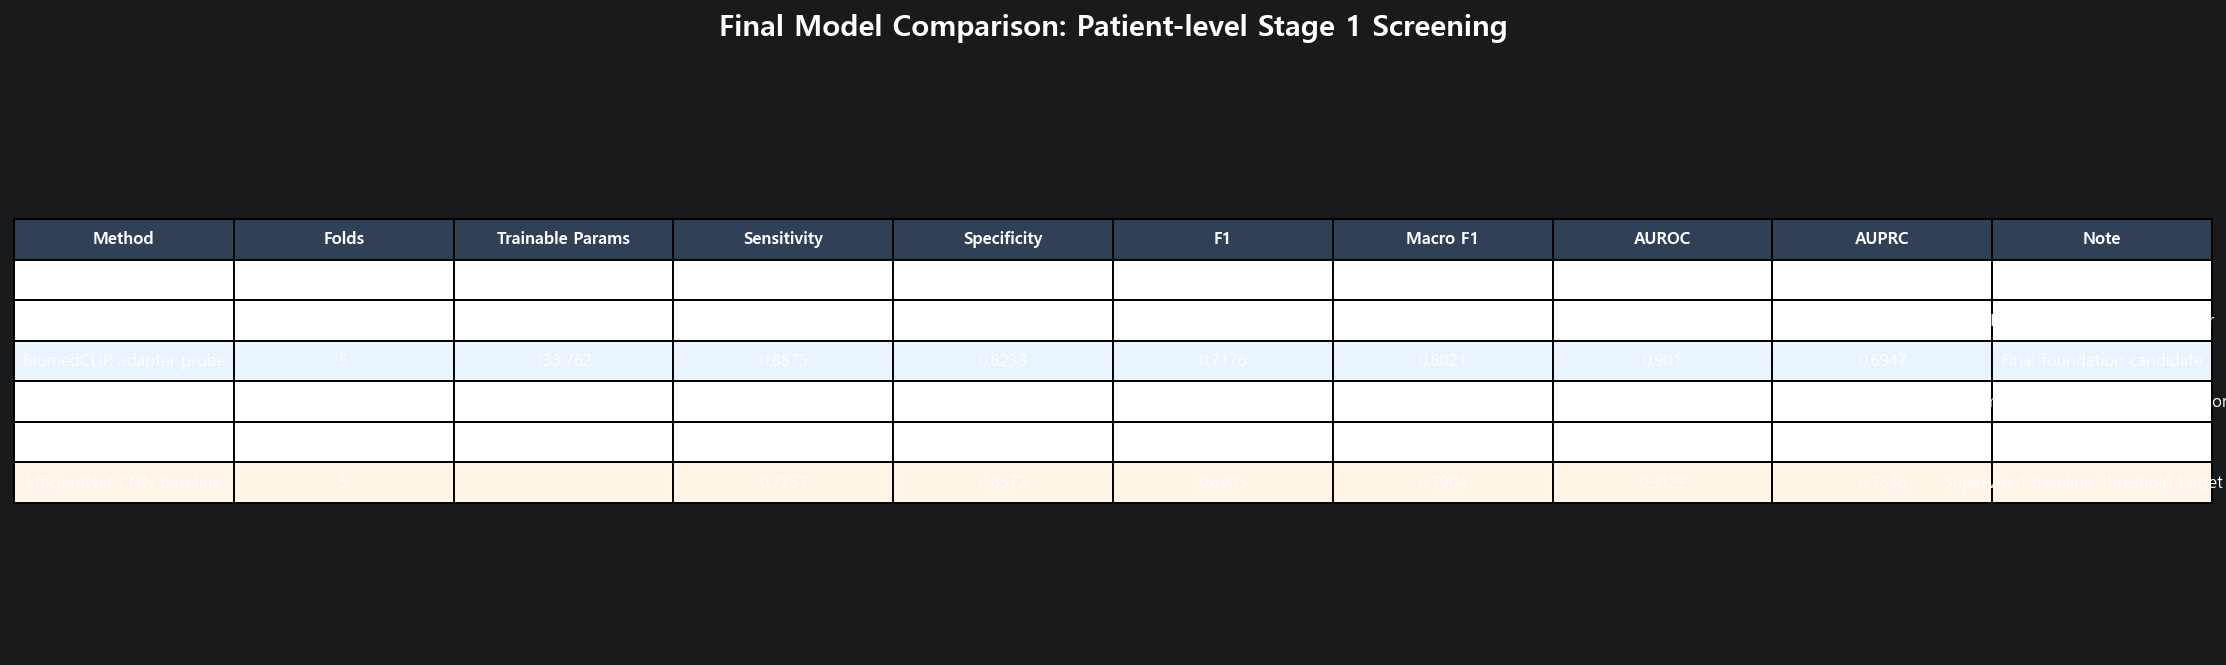

Saved: C:\Users\user\alzheimer\presentation_assets\final_model_comparison_table.png


In [3]:
table_display_cols = [
    "Method", "Folds", "Trainable Params", "Sensitivity", "Specificity",
    "F1", "Macro F1", "AUROC", "AUPRC", "Note",
]
table_for_png = comparison_rounded[table_display_cols].copy()

fig, ax = plt.subplots(figsize=(16, 4.8))
ax.axis("off")
table = ax.table(
    cellText=table_for_png.values,
    colLabels=table_for_png.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.55)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#2f4057")
    elif table_for_png.iloc[row - 1]["Method"] == "BiomedCLIP adapter probe":
        cell.set_facecolor("#eaf4ff")
    elif table_for_png.iloc[row - 1]["Method"] == "EfficientNet CNN baseline":
        cell.set_facecolor("#fff4e6")
    else:
        cell.set_facecolor("#ffffff")

fig.suptitle("Final Model Comparison: Patient-level Stage 1 Screening", fontsize=15, weight="bold")
plt.tight_layout()
out_path = ASSET_DIR / "final_model_comparison_table.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 4. 5-Fold 주요 지표 비교 그래프

Internal adapter는 Fold 1만 실행했기 때문에 5-Fold 평균 그래프에서는 제외합니다.


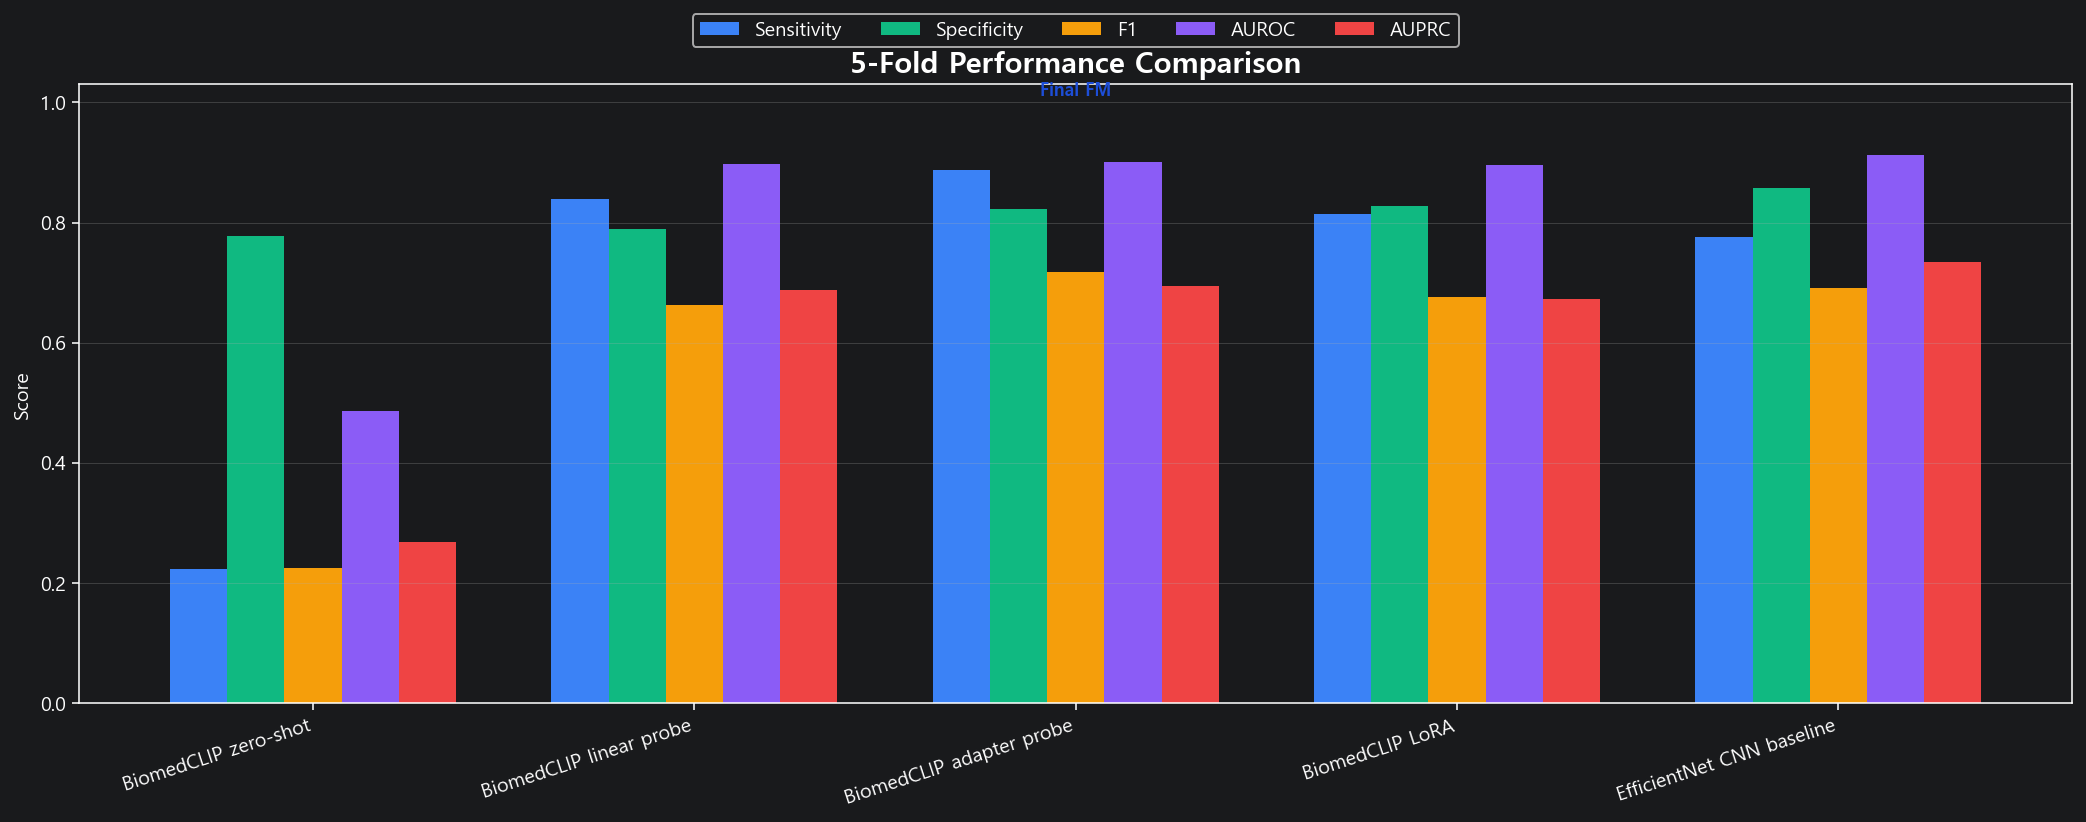

Saved: C:\Users\user\alzheimer\presentation_assets\main_5fold_metric_comparison.png


In [12]:
main_5fold_df = comparison_df[
    (comparison_df["Folds"] >= 5)
    & (comparison_df["Method"] != "BiomedCLIP Internal Adapter")
].copy()

plot_metrics = ["Sensitivity", "Specificity", "F1", "AUROC", "AUPRC"]
long_df = main_5fold_df.melt(
    id_vars=["Method"],
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Score",
)

method_order = [
    "BiomedCLIP zero-shot",
    "BiomedCLIP linear probe",
    "BiomedCLIP adapter probe",
    "BiomedCLIP LoRA",
    "EfficientNet CNN baseline",
]
metric_colors = {
    "Sensitivity": "#3b82f6",
    "Specificity": "#10b981",
    "F1": "#f59e0b",
    "AUROC": "#8b5cf6",
    "AUPRC": "#ef4444",
}

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(method_order))
width = 0.15
for i, metric in enumerate(plot_metrics):
    values = [
        main_5fold_df.loc[main_5fold_df["Method"] == method, metric].iloc[0]
        for method in method_order
    ]
    ax.bar(
        x + (i - 2) * width,
        values,
        width=width,
        label=metric,
        color=metric_colors[metric],
    )

ax.set_xticks(x)
ax.set_xticklabels(method_order, rotation=18, ha="right")
ax.set_ylim(0, 1.03)
ax.set_ylabel("Score")
ax.set_title("5-Fold Performance Comparison", fontsize=15, weight="bold")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=len(plot_metrics), loc="upper center", bbox_to_anchor=(0.5, 1.13))

for method_index, method in enumerate(method_order):
    if method == "BiomedCLIP adapter probe":
        ax.text(method_index, 1.005, "Final FM", ha="center", va="bottom", fontsize=9, weight="bold", color="#1d4ed8")

plt.tight_layout()
out_path = ASSET_DIR / "main_5fold_metric_comparison.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 5. Sensitivity-Specificity 산점도


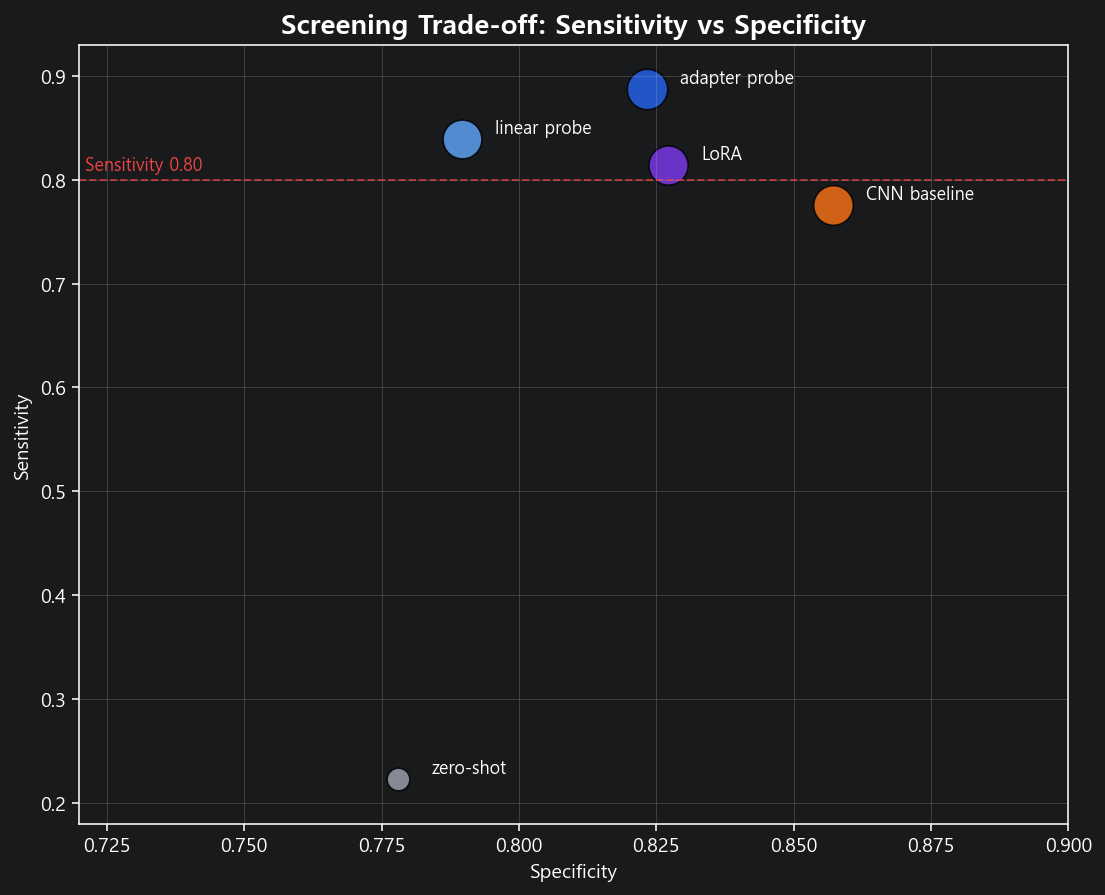

Saved: C:\Users\user\alzheimer\presentation_assets\sensitivity_specificity_scatter.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 6.5))

scatter_df = main_5fold_df.copy()
sizes = 600 * scatter_df["F1"].astype(float).to_numpy()
colors = ["#9ca3af", "#60a5fa", "#2563eb", "#7c3aed", "#f97316"]

for idx, row in scatter_df.iterrows():
    ax.scatter(
        row["Specificity"],
        row["Sensitivity"],
        s=600 * row["F1"],
        color=colors[list(scatter_df.index).index(idx)],
        alpha=0.82,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.text(
        row["Specificity"] + 0.006,
        row["Sensitivity"] + 0.006,
        row["Method"].replace("BiomedCLIP ", "").replace("EfficientNet ", ""),
        fontsize=9,
    )

ax.set_xlim(0.72, 0.90)
ax.set_ylim(0.18, 0.93)
ax.set_xlabel("Specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("Screening Trade-off: Sensitivity vs Specificity", fontsize=14, weight="bold")
ax.grid(alpha=0.25)
ax.axhline(0.80, color="#ef4444", linestyle="--", linewidth=1, alpha=0.7)
ax.text(0.721, 0.805, "Sensitivity 0.80", color="#ef4444", fontsize=9, va="bottom")

plt.tight_layout()
out_path = ASSET_DIR / "sensitivity_specificity_scatter.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 6. 파라미터 효율성 그래프


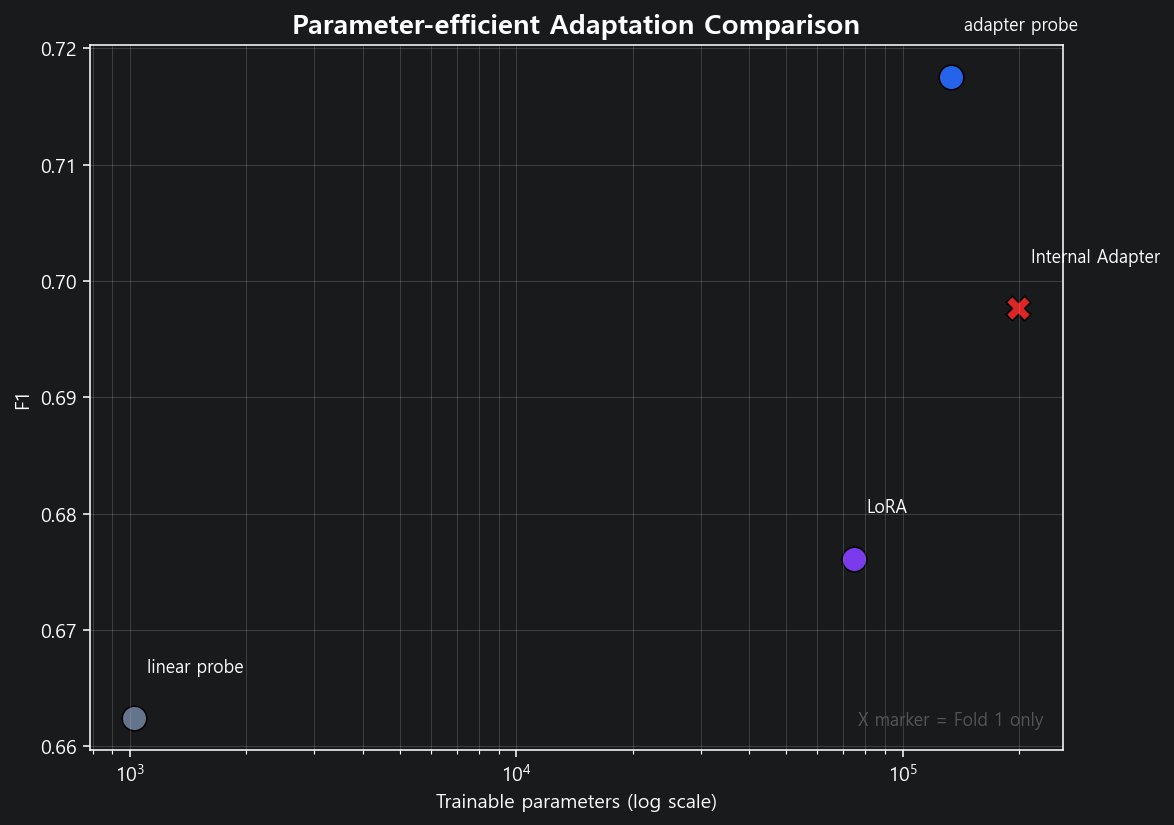

Saved: C:\Users\user\alzheimer\presentation_assets\parameter_efficiency.png


In [6]:
param_df = comparison_df[
    comparison_df["Method"].isin([
        "BiomedCLIP linear probe",
        "BiomedCLIP adapter probe",
        "BiomedCLIP LoRA",
        "BiomedCLIP Internal Adapter",
    ])
].copy()

fig, ax = plt.subplots(figsize=(8.5, 6))
for _, row in param_df.iterrows():
    marker = "o" if row["Folds"] >= 5 else "X"
    color = "#2563eb" if row["Method"] == "BiomedCLIP adapter probe" else "#64748b"
    if row["Method"] == "BiomedCLIP LoRA":
        color = "#7c3aed"
    if row["Method"] == "BiomedCLIP Internal Adapter":
        color = "#dc2626"
    ax.scatter(
        row["Trainable Params"],
        row["F1"],
        s=160,
        marker=marker,
        color=color,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.text(
        row["Trainable Params"] * 1.08,
        row["F1"] + 0.004,
        row["Method"].replace("BiomedCLIP ", ""),
        fontsize=9,
    )

ax.set_xscale("log")
ax.set_xlabel("Trainable parameters (log scale)")
ax.set_ylabel("F1")
ax.set_title("Parameter-efficient Adaptation Comparison", fontsize=14, weight="bold")
ax.grid(alpha=0.25, which="both")
ax.text(
    0.98,
    0.03,
    "X marker = Fold 1 only",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="#555",
)

plt.tight_layout()
out_path = ASSET_DIR / "parameter_efficiency.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 7. Fold 1 PEFT 비교 그래프


,Method,Sensitivity,Specificity,F1,AUROC,AUPRC
0,Adapter probe,0.8750,0.8333,0.7179,0.9074,0.7102
1,LoRA,0.9375,0.7963,0.7143,0.8947,0.6219
2,Internal adapter,0.9375,0.7778,0.6977,0.9016,0.6419


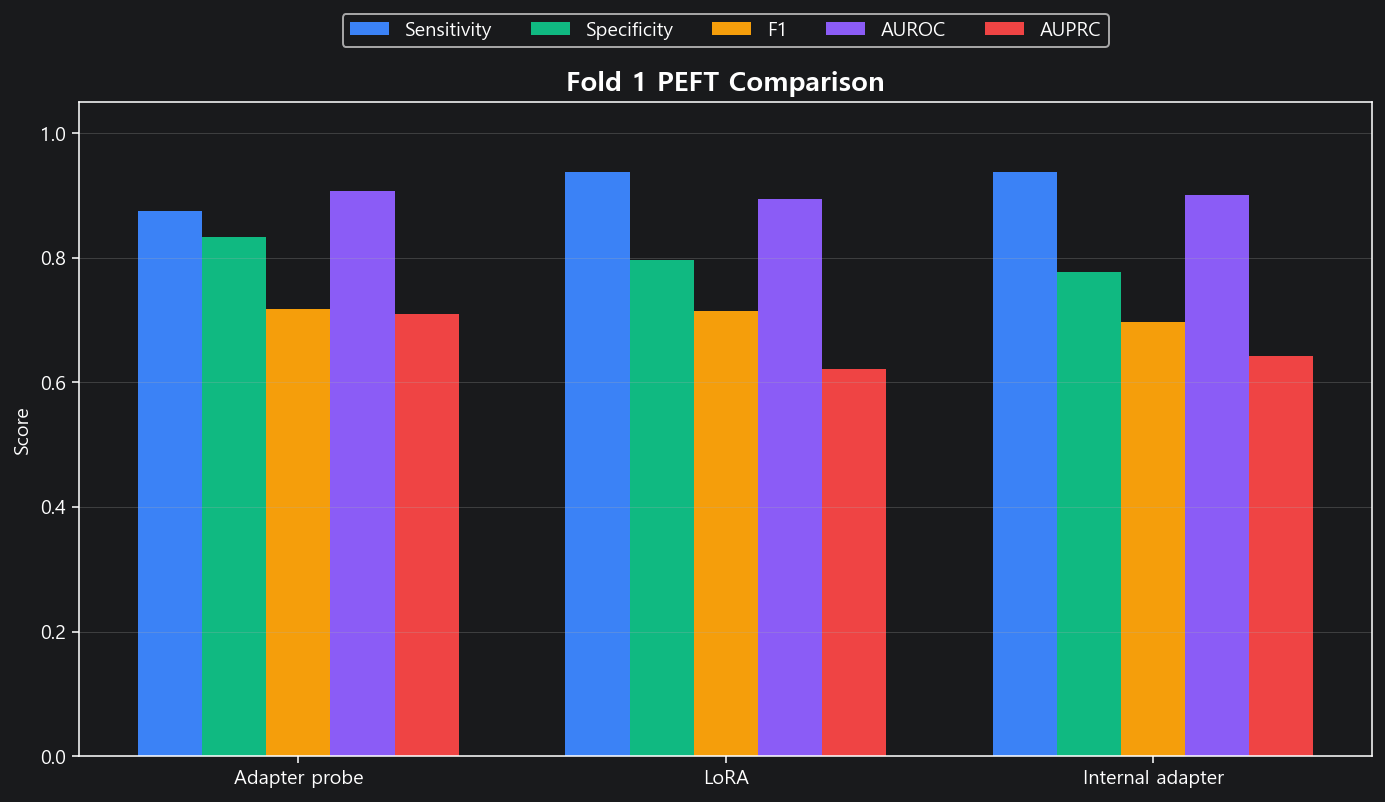

Saved: C:\Users\user\alzheimer\presentation_assets\fold1_peft_comparison.png


In [7]:
adapter_fold1 = foundation_folds[
    (foundation_folds["experiment"] == "adapter_probe")
    & (foundation_folds["fold"] == 1)
].iloc[0]
lora_fold1 = lora_folds[lora_folds["fold"] == 1].iloc[0]
internal_fold1 = internal_folds[internal_folds["fold"] == 1].iloc[0]

fold1_rows = []
for label, row in [
    ("Adapter probe", adapter_fold1),
    ("LoRA", lora_fold1),
    ("Internal adapter", internal_fold1),
]:
    fold1_rows.append({
        "Method": label,
        "Sensitivity": row["calibrated_sensitivity"],
        "Specificity": row["calibrated_specificity"],
        "F1": row["calibrated_f1"],
        "AUROC": row["auroc"],
        "AUPRC": row["auprc"],
    })
fold1_df = pd.DataFrame(fold1_rows)
display(fold1_df.round(4))

fold1_long = fold1_df.melt(id_vars="Method", var_name="Metric", value_name="Score")
metrics = ["Sensitivity", "Specificity", "F1", "AUROC", "AUPRC"]

fig, ax = plt.subplots(figsize=(10, 5.8))
x = np.arange(len(fold1_df))
width = 0.15
for i, metric in enumerate(metrics):
    values = fold1_df[metric].values
    ax.bar(
        x + (i - 2) * width,
        values,
        width=width,
        label=metric,
        color=metric_colors.get(metric, "#888"),
    )

ax.set_xticks(x)
ax.set_xticklabels(fold1_df["Method"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Fold 1 PEFT Comparison", fontsize=14, weight="bold")
ax.grid(axis="y", alpha=0.25)
ax.legend(ncol=len(metrics), loc="upper center", bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
out_path = ASSET_DIR / "fold1_peft_comparison.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 8. 알고리즘 파이프라인 그림


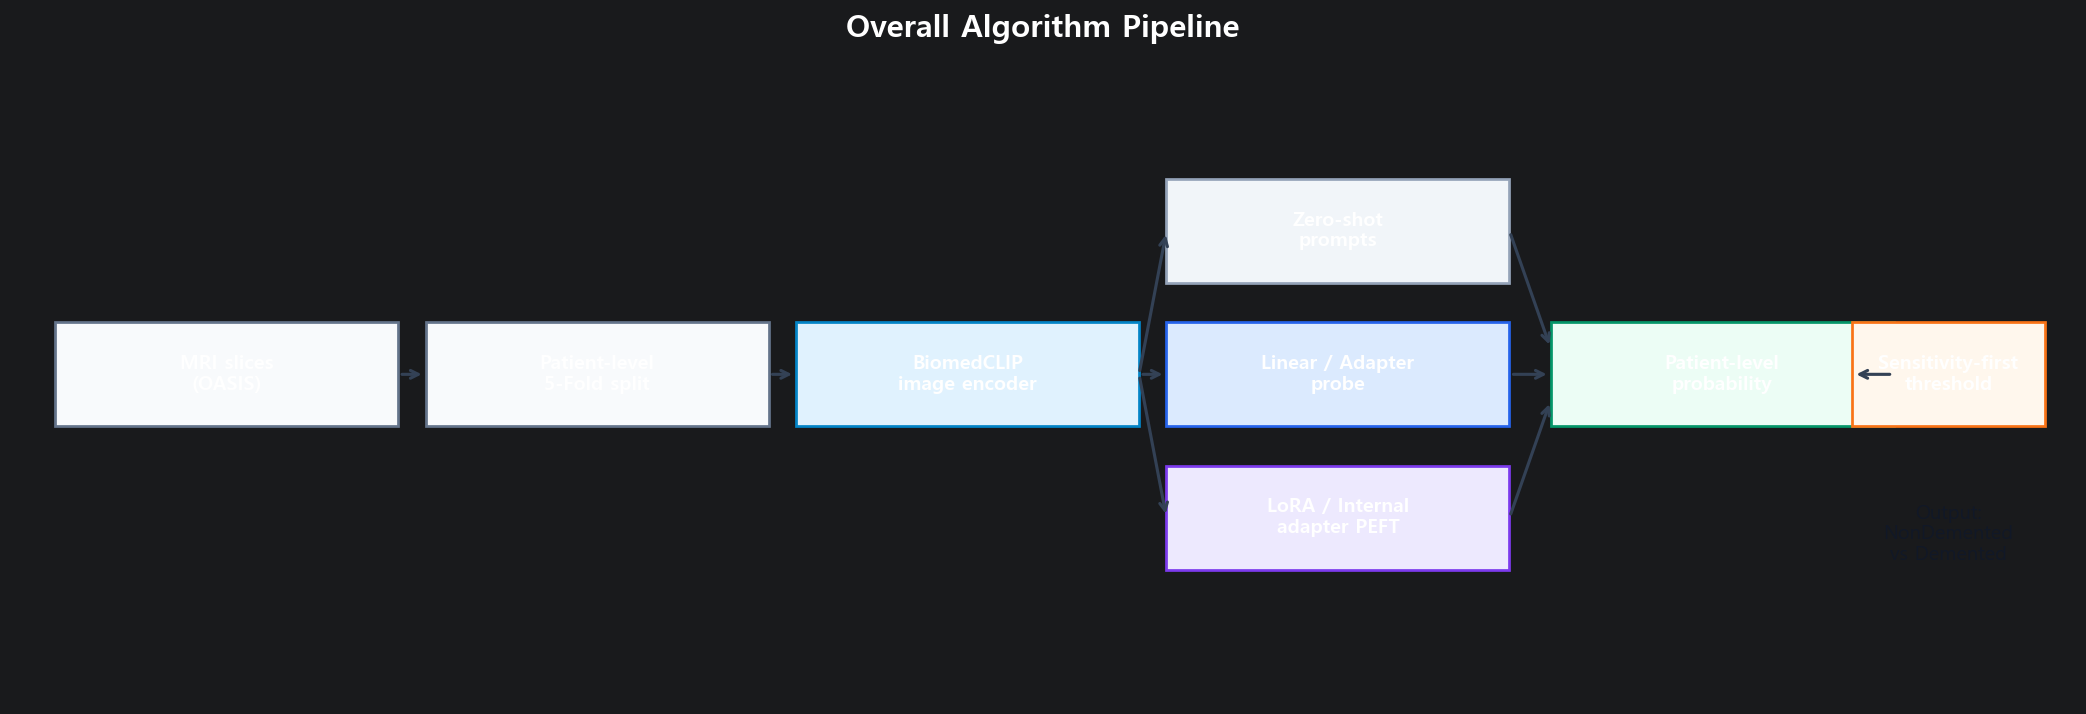

Saved: C:\Users\user\alzheimer\presentation_assets\pipeline_diagram.png


In [8]:
def draw_box(ax, xy, text, width=2.5, height=0.8, color="#eaf4ff", edge="#1d4ed8"):
    x, y = xy
    rect = plt.Rectangle((x, y), width, height, facecolor=color, edgecolor=edge, linewidth=1.4)
    ax.add_patch(rect)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=10, weight="bold")
    return rect


def draw_arrow(ax, start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.6, color="#334155"),
    )


fig, ax = plt.subplots(figsize=(15, 5.2))
ax.set_xlim(0, 15)
ax.set_ylim(0, 5)
ax.axis("off")

draw_box(ax, (0.3, 2.1), "MRI slices\n(OASIS)", color="#f8fafc", edge="#64748b")
draw_box(ax, (3.0, 2.1), "Patient-level\n5-Fold split", color="#f8fafc", edge="#64748b")
draw_box(ax, (5.7, 2.1), "BiomedCLIP\nimage encoder", color="#e0f2fe", edge="#0284c7")
draw_box(ax, (8.4, 3.2), "Zero-shot\nprompts", color="#f1f5f9", edge="#94a3b8")
draw_box(ax, (8.4, 2.1), "Linear / Adapter\nprobe", color="#dbeafe", edge="#2563eb")
draw_box(ax, (8.4, 1.0), "LoRA / Internal\nadapter PEFT", color="#ede9fe", edge="#7c3aed")
draw_box(ax, (11.2, 2.1), "Patient-level\nprobability", color="#ecfdf5", edge="#059669")
draw_box(ax, (13.4, 2.1), "Sensitivity-first\nthreshold", width=1.4, color="#fff7ed", edge="#f97316")

draw_arrow(ax, (2.8, 2.5), (3.0, 2.5))
draw_arrow(ax, (5.5, 2.5), (5.7, 2.5))
draw_arrow(ax, (8.2, 2.5), (8.4, 3.6))
draw_arrow(ax, (8.2, 2.5), (8.4, 2.5))
draw_arrow(ax, (8.2, 2.5), (8.4, 1.4))
draw_arrow(ax, (10.9, 3.6), (11.2, 2.7))
draw_arrow(ax, (10.9, 2.5), (11.2, 2.5))
draw_arrow(ax, (10.9, 1.4), (11.2, 2.3))
draw_arrow(ax, (13.7, 2.5), (13.4, 2.5))

ax.text(14.1, 1.5, "Output:\nNonDemented\nvs Demented", ha="center", va="top", fontsize=10, color="#111827")
ax.set_title("Overall Algorithm Pipeline", fontsize=16, weight="bold")

plt.tight_layout()
out_path = ASSET_DIR / "pipeline_diagram.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 9. 발표용 요약문 및 pseudo-code 생성


In [9]:
adapter = comparison_df[comparison_df["Method"] == "BiomedCLIP adapter probe"].iloc[0]
cnn = comparison_df[comparison_df["Method"] == "EfficientNet CNN baseline"].iloc[0]
lora = comparison_df[comparison_df["Method"] == "BiomedCLIP LoRA"].iloc[0]

summary_text = f"""# Presentation Summary

## Project Question

Can a biomedical foundation model transfer to Alzheimer MRI screening, and how much task-specific adaptation is needed?

## Problem Definition

- Input: 2D MRI slice images from OASIS-style patient IDs
- Output: patient-level binary prediction
- Negative class: NonDemented
- Positive class: Demented = VeryMildDemented + MildDemented + ModerateDemented
- Evaluation: patient-level 5-Fold split

## Main Results

| Method | Sensitivity | Specificity | F1 | AUROC | AUPRC | Trainable Params |
|---|---:|---:|---:|---:|---:|---:|
| BiomedCLIP zero-shot | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP zero-shot', 'Sensitivity'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP zero-shot', 'Specificity'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP zero-shot', 'F1'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP zero-shot', 'AUROC'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP zero-shot', 'AUPRC'].iloc[0]:.3f} | 0 |
| Linear probe | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP linear probe', 'Sensitivity'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP linear probe', 'Specificity'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP linear probe', 'F1'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP linear probe', 'AUROC'].iloc[0]:.3f} | {comparison_df.loc[comparison_df.Method == 'BiomedCLIP linear probe', 'AUPRC'].iloc[0]:.3f} | 1,026 |
| Adapter probe | {adapter['Sensitivity']:.3f} | {adapter['Specificity']:.3f} | {adapter['F1']:.3f} | {adapter['AUROC']:.3f} | {adapter['AUPRC']:.3f} | {int(adapter['Trainable Params']):,} |
| LoRA | {lora['Sensitivity']:.3f} | {lora['Specificity']:.3f} | {lora['F1']:.3f} | {lora['AUROC']:.3f} | {lora['AUPRC']:.3f} | {int(lora['Trainable Params']):,} |
| CNN baseline | {cnn['Sensitivity']:.3f} | {cnn['Specificity']:.3f} | {cnn['F1']:.3f} | {cnn['AUROC']:.3f} | {cnn['AUPRC']:.3f} | not counted |

## Interpretation

BiomedCLIP zero-shot did not transfer well to Alzheimer MRI screening. This suggests that direct prompt-based use of a biomedical foundation model is not sufficient for subtle MRI-based dementia classification.

Frozen BiomedCLIP features became useful after task-specific learning. The linear probe improved substantially, and the adapter probe produced the most stable foundation-model result.

LoRA and internal adapter fine-tuning tested deeper parameter-efficient adaptation. However, in the current data setting, these model-internal PEFT methods did not outperform the simpler frozen-feature adapter probe.

The CNN baseline achieved strong AUROC/AUPRC, but the adapter probe reached competitive screening performance while training only {int(adapter['Trainable Params']):,} parameters, which supports the parameter-efficient foundation model narrative.

## Slide Pseudo-code

```python
# Patient-level split
patient_id = extract_patient_id(filename)
folds = StratifiedKFold(patient_table, label="NonDemented vs Demented")

# BiomedCLIP frozen feature
with torch.inference_mode():
    z = biomedclip.encode_image(mri_slice)

# Adapter probe
z = LayerNorm(z)
z = z + Adapter(z)
logits = Linear(z)

# Patient-level aggregation
slice_probs = softmax(logits)[:, 1]
patient_prob = mean(slice_probs grouped by patient_id)

# Screening decision
prediction = patient_prob >= sensitivity_first_threshold
```

## Final Conclusion

The best foundation-model strategy in this project was frozen BiomedCLIP feature extraction followed by an adapter probe. More invasive PEFT methods were informative but did not provide a stable advantage. This supports the conclusion that, for this small Alzheimer MRI dataset, preserving the foundation model and adapting a small task-specific head is the most reliable approach.
"""

summary_path = ASSET_DIR / "presentation_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")
print(summary_text)
print(f"Saved: {summary_path}")


# Presentation Summary

## Project Question

Can a biomedical foundation model transfer to Alzheimer MRI screening, and how much task-specific adaptation is needed?

## Problem Definition

- Input: 2D MRI slice images from OASIS-style patient IDs
- Output: patient-level binary prediction
- Negative class: NonDemented
- Positive class: Demented = VeryMildDemented + MildDemented + ModerateDemented
- Evaluation: patient-level 5-Fold split

## Main Results

| Method | Sensitivity | Specificity | F1 | AUROC | AUPRC | Trainable Params |
|---|---:|---:|---:|---:|---:|---:|
| BiomedCLIP zero-shot | 0.223 | 0.778 | 0.225 | 0.486 | 0.268 | 0 |
| Linear probe | 0.839 | 0.790 | 0.662 | 0.898 | 0.687 | 1,026 |
| Adapter probe | 0.887 | 0.823 | 0.718 | 0.901 | 0.695 | 133,762 |
| LoRA | 0.814 | 0.827 | 0.676 | 0.896 | 0.673 | 74,754 |
| CNN baseline | 0.776 | 0.857 | 0.690 | 0.912 | 0.734 | not counted |

## Interpretation

BiomedCLIP zero-shot did not transfer well to Alzheimer MRI screening. This 

## 10. 생성된 파일 목록


In [10]:
generated_files = sorted(ASSET_DIR.glob("*"))
for path in generated_files:
    print(path.name)


final_model_comparison_table.csv
final_model_comparison_table.png
fold1_peft_comparison.png
main_5fold_metric_comparison.png
parameter_efficiency.png
pipeline_diagram.png
presentation_summary.md
sensitivity_specificity_scatter.png
